# Análise Exploratória dos Dados

Nessa etapa, iremos explorar os nossos dados, analisando estatísticas, correlações, valores faltantes e outliers.

## Importando as Bibliotecas

Vamos carregar nossas bibliotecas.

In [179]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

## Carregando o Dataset

Agora vamos carregar o nosso dataset.

In [180]:
df = pd.read_parquet("../data/processed/02_enriched.parquet")

In [181]:
df.info()

<class 'pandas.DataFrame'>
Index: 7253 entries, 0 to 9838
Data columns (total 76 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   preco                 7253 non-null   Int64  
 1   condominio            5627 non-null   Int64  
 2   iptu                  4258 non-null   Int64  
 3   tamanho               7253 non-null   Int64  
 4   quartos               7252 non-null   Int64  
 5   banheiros             7252 non-null   Int64  
 6   vagas_estacionamento  7051 non-null   Int64  
 7   andar                 3262 non-null   Int64  
 8   piscina               7253 non-null   boolean
 9   elevador              7253 non-null   boolean
 10  churrasqueira         7253 non-null   boolean
 11  condominio_fechado    7253 non-null   boolean
 12  academia              7253 non-null   boolean
 13  espaco_gourmet        7253 non-null   boolean
 14  jardim                7253 non-null   boolean
 15  parque_infantil       7253 non-null  

## Análise de Correlação

Vamos inicialmente fazer uma análise de correlação entre algumas variáveis. Para isso, vamos remover a feature `endereco` e vamos converter todas as features para o tipo `float`.

In [182]:
df = df.astype("float")

In [183]:
df.head(10)

,preco,condominio,iptu,tamanho,quartos,banheiros,vagas_estacionamento,andar,piscina,elevador,...,gramado,janelas_grandes,ventilacao_natural,fogao,trilha_caminhada,vista_panoramica,massagem,freezer,latitude,longitude
index,,,,,,,,,,,,,,,,,,,,,
0,949900.0,790.0,1900.0,130.0,3.0,4.0,2.0,24.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.709058,-49.277839
1,760000.0,NaN,NaN,100.0,3.0,3.0,2.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.665117,-49.233589
2,350000.0,270.0,250.0,57.0,2.0,1.0,1.0,19.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.742692,-49.286282
3,523000.0,500.0,800.0,74.0,3.0,3.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.711875,-49.321283
4,624700.0,500.0,900.0,72.0,2.0,1.0,1.0,8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.737753,-49.280492
5,374813.0,NaN,NaN,61.0,2.0,2.0,1.0,7.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.740504,-49.294985
6,700000.0,700.0,900.0,100.0,3.0,4.0,2.0,NaN,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.689436,-49.277837
7,450000.0,350.0,NaN,58.0,2.0,2.0,1.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.741104,-49.293297
8,420000.0,NaN,NaN,79.0,3.0,2.0,2.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.681611,-49.281547


In [184]:
corr = df.corr(method="spearman")

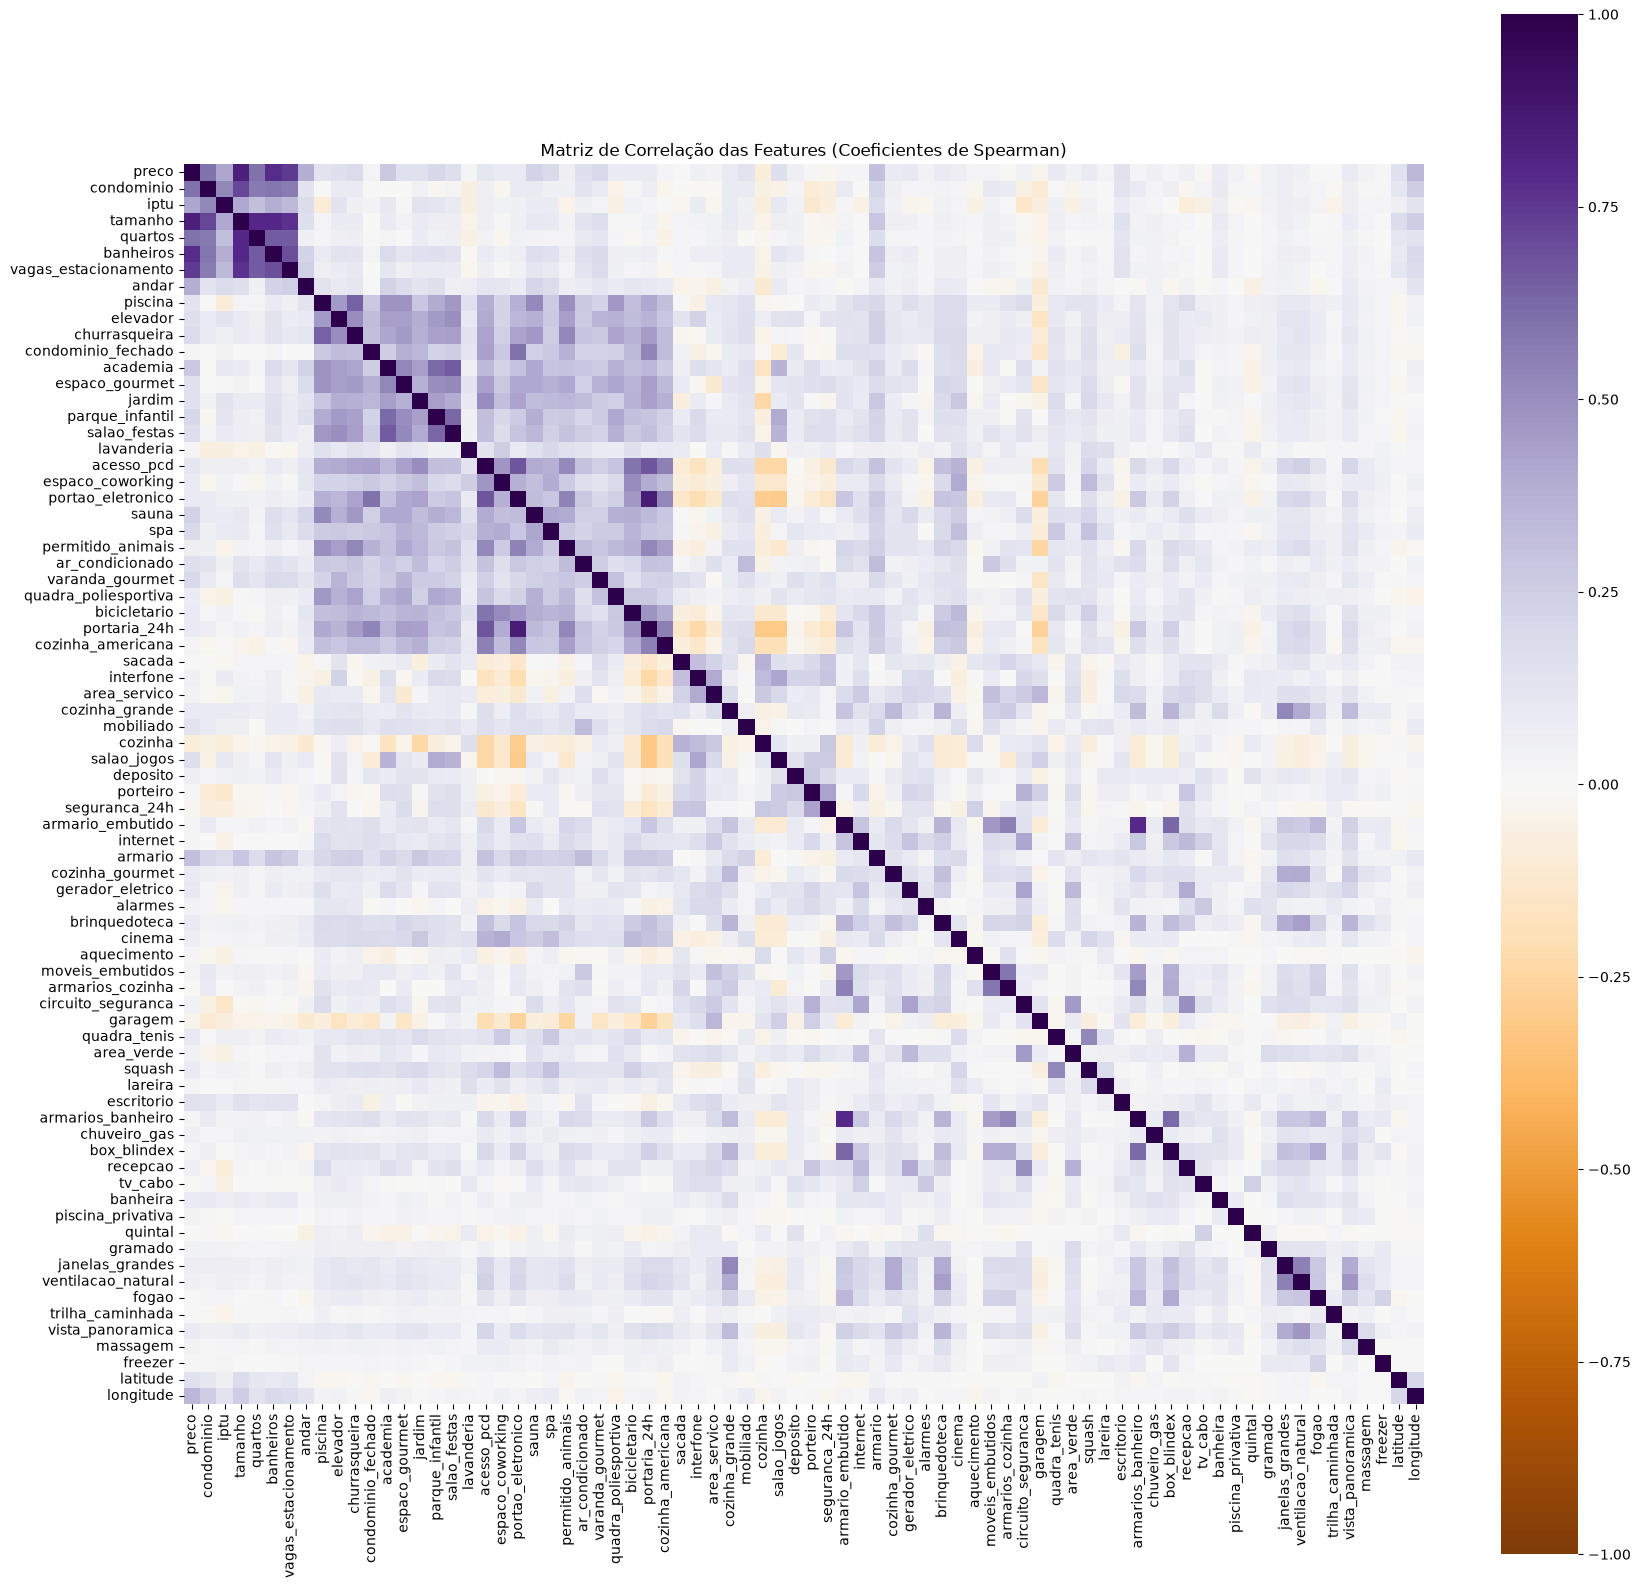

In [185]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.heatmap(
    data=corr,
    annot=False,
    cmap="PuOr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de Correlação das Features (Coeficientes de Spearman)")

plt.show()

Como podemos ver, as features `tamanho`, `banheiros` e `vagas_estacionamento` possuem uma correlação positiva alta com a variável alvo `preço`. Podemos esperar que essas features tenham um bom poder preditivo quando treinarmos nossos modelos, então não seria surpresa se durante a etapa de modelagem nos depararmos com um valor alto de importância para essas features. Além disso, os pares (`portaria_24h`, `portao_eletronico`) e (`armarios_banheiro`, `armario_embutido`) tambem possuem correlação positiva alta, podendo indicar redundância.

Agora, vamos analisar os valores de correlação das primeiras 7 features.

In [186]:
corr_7 = df[df.columns[:7]].corr(method="spearman")

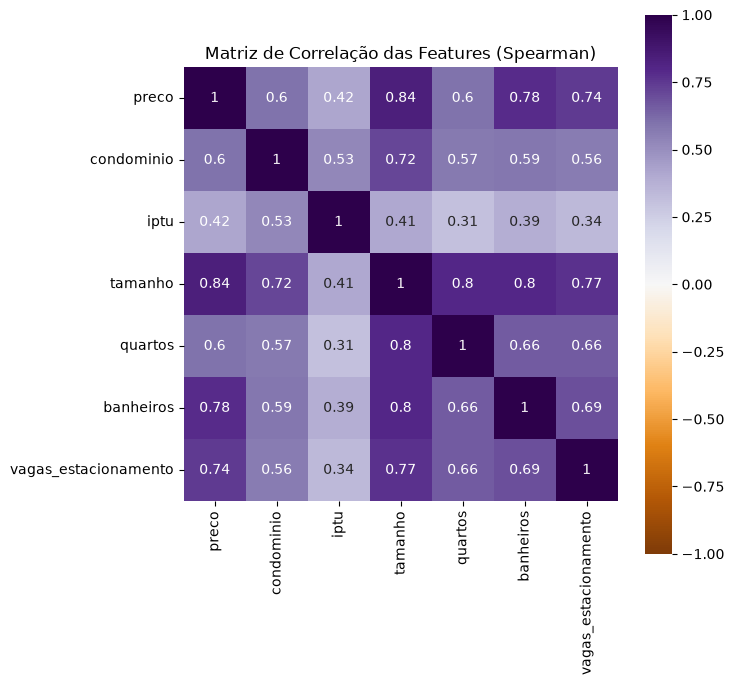

In [187]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

sns.heatmap(
    data=corr_7,
    annot=True,
    cmap="PuOr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de Correlação das Features (Spearman)")

plt.show()

Esses valores podem nos dar uma noção de como nossos modelos vão se comportar na etapa de modelagem.

## Análise de Dados Faltantes

Agora vamos olhar para os dados faltantes do nosso dataset. Primeiro, vamos olhar as porcentagens de dados faltantes nas features do nosso dataset.

In [188]:
df_na_count = df.isna().sum()
total = df.shape[0]

df_missing = pd.DataFrame({
    "Contagem de NA": df_na_count,
    "Porcentagem": (100*df_na_count / total).round(2),
})

df_missing = df_missing.sort_values(
    by="Contagem de NA",
    ascending=False
)

print(df_missing.to_string())

                      Contagem de NA  Porcentagem
andar                           3991        55.03
iptu                            2995        41.29
condominio                      1626        22.42
vagas_estacionamento             202         2.79
banheiros                          1         0.01
quartos                            1         0.01
tamanho                            0         0.00
preco                              0         0.00
piscina                            0         0.00
elevador                           0         0.00
churrasqueira                      0         0.00
condominio_fechado                 0         0.00
academia                           0         0.00
espaco_gourmet                     0         0.00
jardim                             0         0.00
parque_infantil                    0         0.00
salao_festas                       0         0.00
lavanderia                         0         0.00
acesso_pcd                         0         0.00


Como podemos ver, apenas as features `andar`, `iptu`, `condominio`, `vagas_estacionamento`, `banheiros` e `quartos` possuem valores faltantes, sendo esses $3$ últimos de baixíssima frequência. Como as duas últimas possuem uma quantidade muito baixa de valores faltantes, então vamos prosseguir a análise apenas com as $4$ primeiras features.

In [189]:
df_miss = df[["andar", "iptu", "condominio", "vagas_estacionamento"]]

<Axes: >

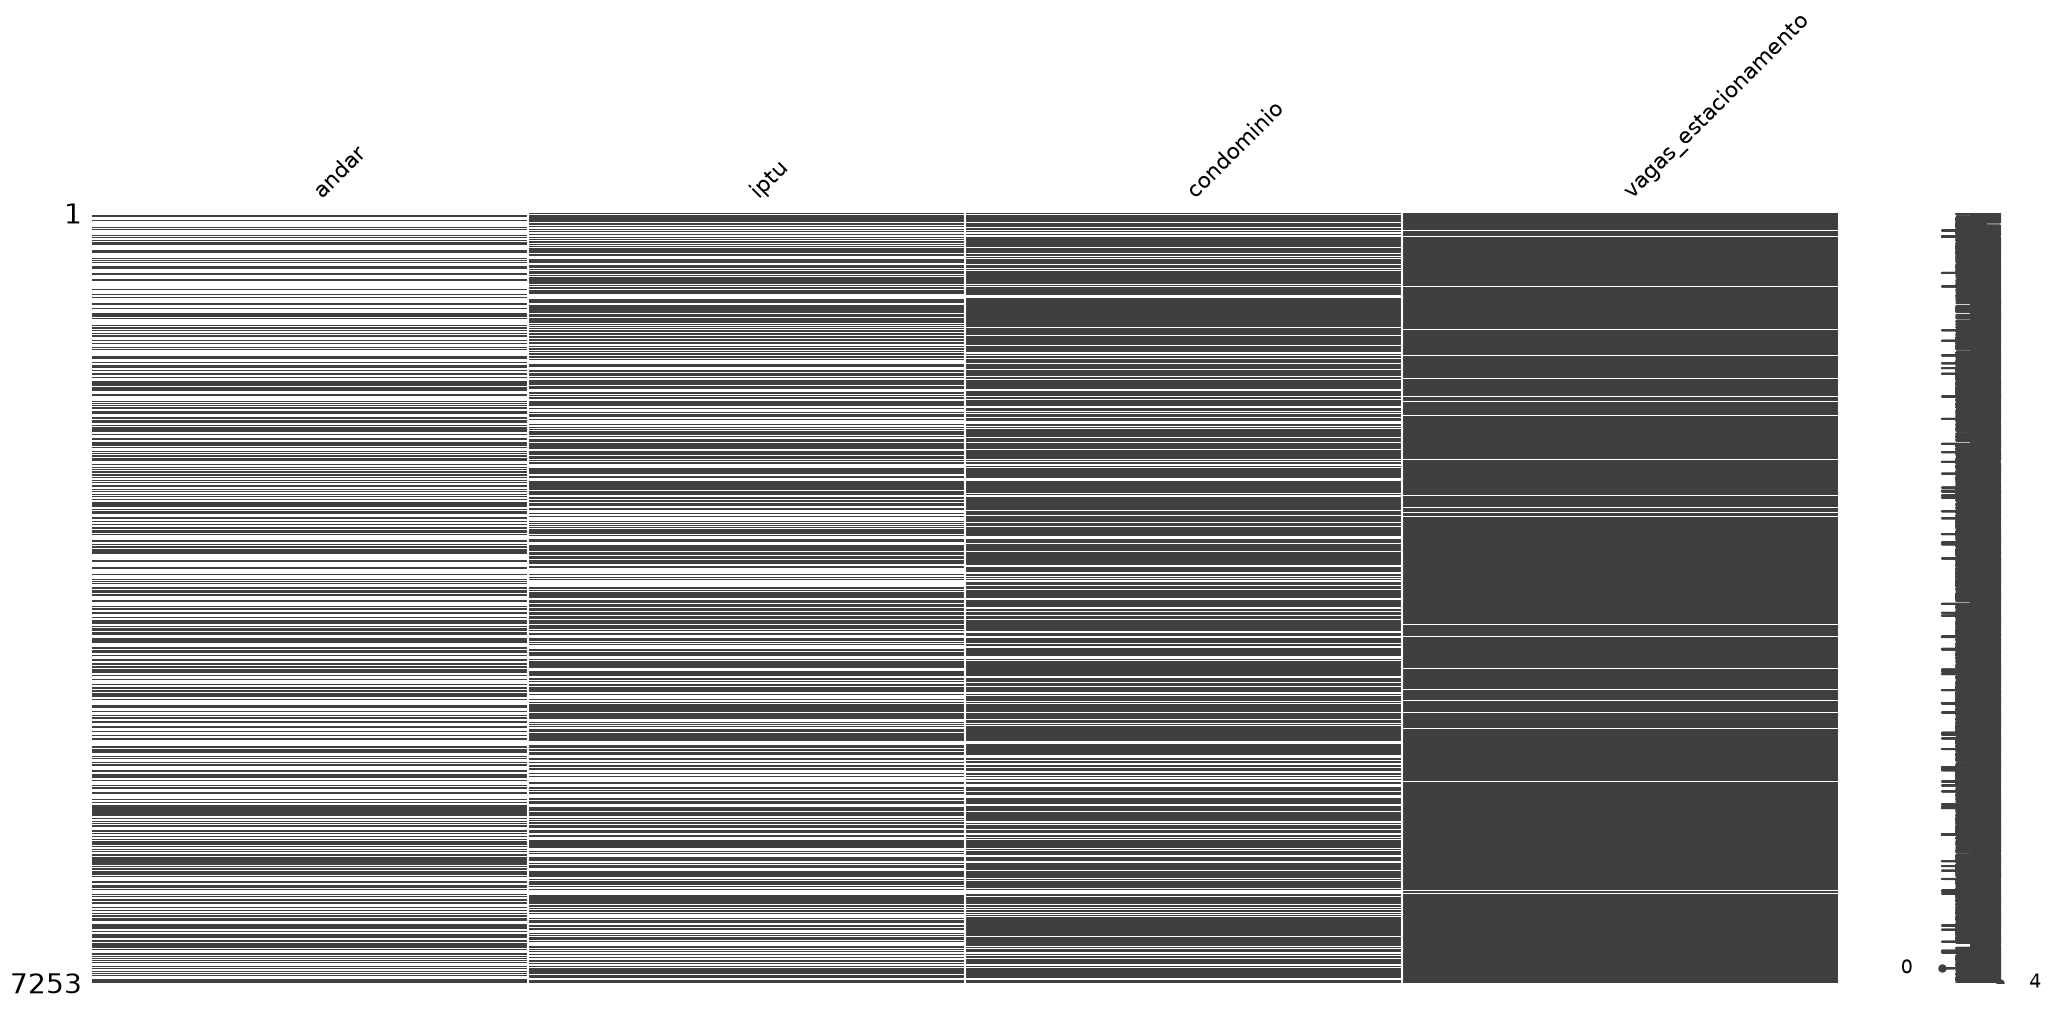

In [190]:
msno.matrix(df_miss)

Bom, a princípio não parece ter nenhum padrão nos valores faltantes. Vamos então olhar para as correlações dos valores faltantes dessas features.

<Axes: >

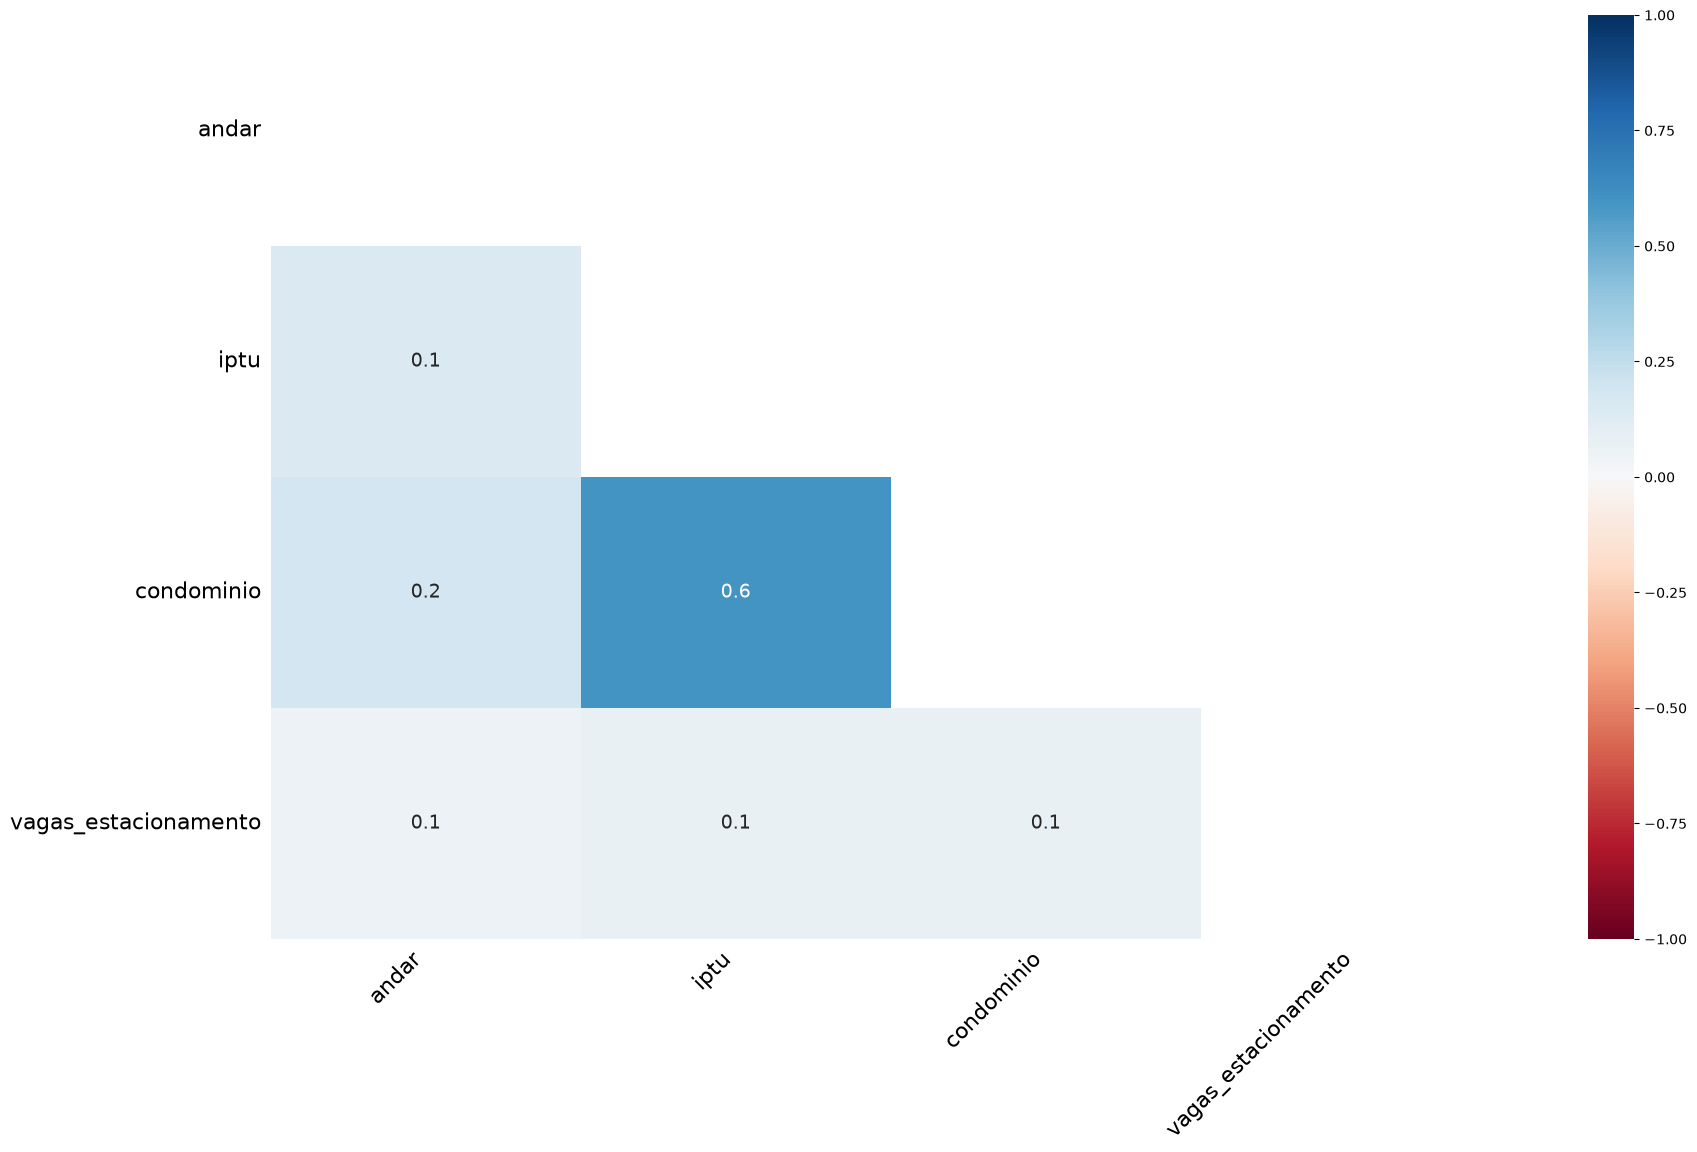

In [191]:
msno.heatmap(df_miss)

Como podemos ver, apenas o par `condominio` e `iptu` têm uma correlação de valores faltantes mediana, o que faz sentido se pensarmos que ambas têm alguma relação pois são valores pagos mensalmente em relação ao imóvel. Agora vamos olhar para o dendrograma do nosso dataset.

<Axes: >

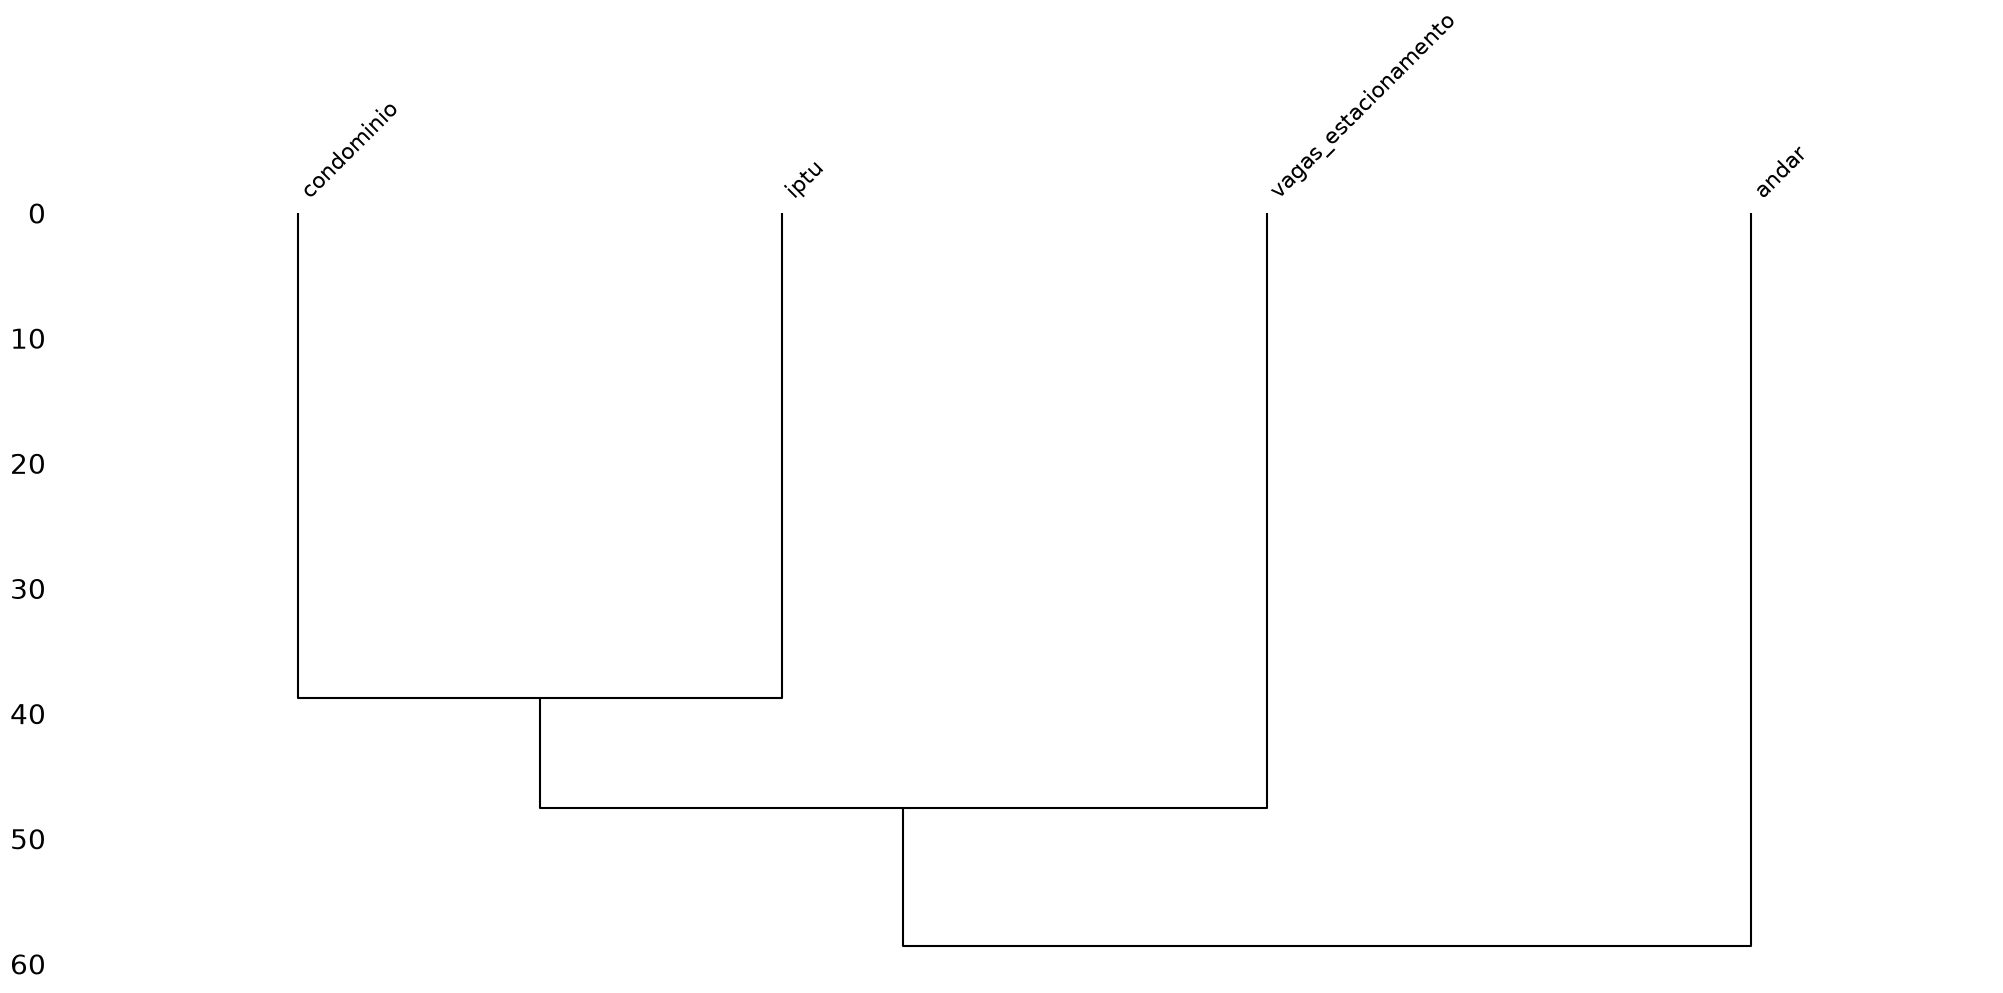

In [192]:
msno.dendrogram(df_miss)

Como visto antes, os valores faltantes de `condominio` e `iptu` são bem parecidos, seguidos respectivamente por `vagas_estacionamento` e `andar`. Com essas informações podemos concluir que existe um padrão entre os valores faltantes de `condomínio` e `iptu`, mas a relação não é forte o suficiente para considerarmos isso um problema. Além disso, a variável `andar` tem muitos valores faltantes, o que pode ser um problema na etapa de modelagem. Por hora vou considerar os valores faltantes como MAR (Missing at Random). Dessa forma, na etapa de modelagem iremos preencher os valores faltantes para os modelos que não os suportam e vou mantê-los para os modelos que os suportam.

## Análise de Outliers

Para fazermos a análise de outliers, vamos treinar um modelo de aprendizado não supervisionado chamado Isolation Forest, que é um modelo de detecção de anomalias.

In [193]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.impute import (
    SimpleImputer,
    KNNImputer,
)

random_state = 1667

imputer = KNNImputer(
    n_neighbors=10,
)

detector = IsolationForest(
    n_estimators=500,
    random_state=random_state,
    verbose=1,
)

pipeline = Pipeline(steps=[
    ("imputer", imputer),
    ("detector", detector)
])

Além das features que temos, vamos adicionar também a feature `preco_m2`, para calcular o preço por metro quadrado do imóvel.

In [194]:
df["preco_m2"] = df["preco"] / df["tamanho"]

In [195]:
X = df.values

In [196]:
pipeline.fit(X)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('detector', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,77
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",10
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True


In [197]:
outlier = pipeline.predict(X)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:    0.2s finished


In [198]:
df["outlier"] = outlier
df["outlier"] = df["outlier"].map({1: "normal", -1: "outlier"})

Agora, vamos plotar alguns gráficos de dispersão para entendermos melhor esses outliers.

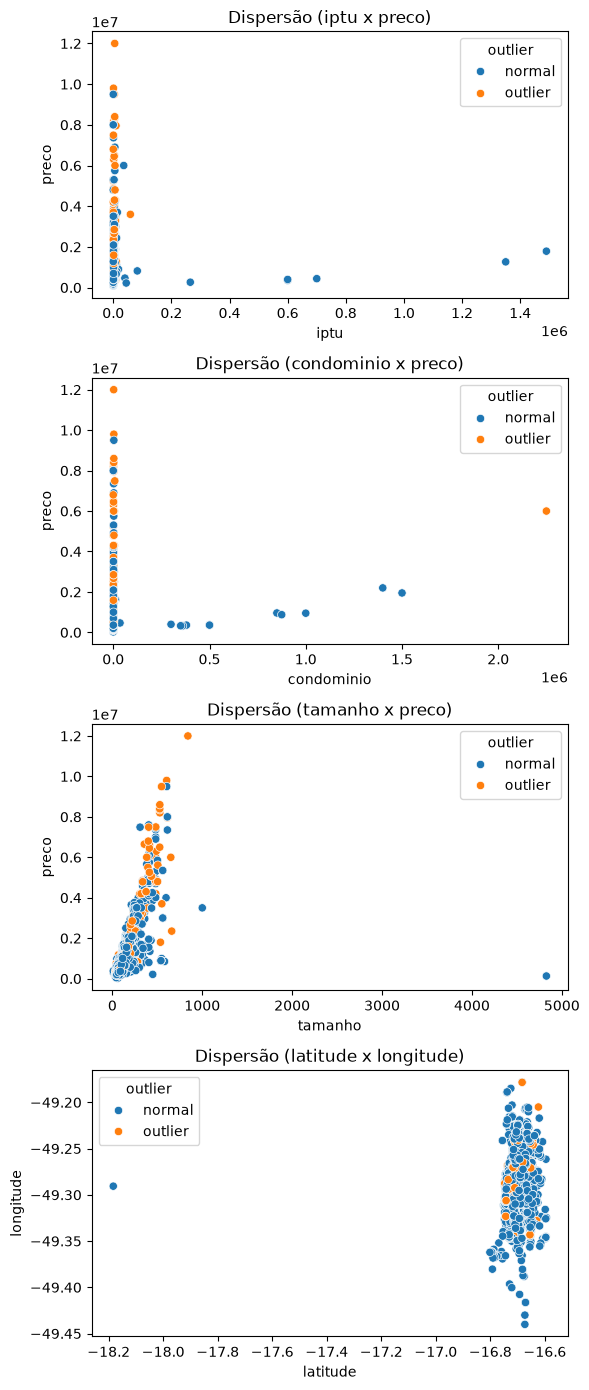

In [199]:
fig, ax = plt.subplots(4, 1, figsize=(6, 14))

for i, feature in enumerate(["iptu", "condominio", "tamanho"]):
    sns.scatterplot(data=df, x=feature, y="preco", hue="outlier", ax=ax[i])
    ax[i].set_title(f"Dispersão ({feature} x preco)")

sns.scatterplot(data=df, x="latitude", y="longitude", hue="outlier", ax=ax[3])
ax[3].set_title("Dispersão (latitude x longitude)")

plt.tight_layout()
plt.show()